## 1. Importação de Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregar Dataset


In [4]:
df = pd.read_csv('urldata.csv', encoding='latin1', low_memory=False)

print(f'Linhas   : {df.shape[0]:,}')
print(f'Colunas  : {df.shape[1]}')
print(f'\nColunas: {df.columns.tolist()}')

Linhas   : 95,913
Colunas  : 14

Colunas: ['domain', 'ranking', 'mld_res', 'mld.ps_res', 'card_rem', 'ratio_Rrem', 'ratio_Arem', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem', 'label']


In [5]:
df.head()

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1,0,18,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0,0,11,150.636364,152.272727,0.0,0.0,0.0,0.0,0.0,0.768577,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0,0,14,73.500000,72.642857,0.0,0.0,0.0,0.0,0.0,0.726582,1
3,mail.printakid.com/www.online.americanexpress....,10000000,0,0,6,562.000000,590.666667,0.0,0.0,0.0,0.0,0.0,0.859640,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0,0,8,29.000000,24.125000,0.0,0.0,0.0,0.0,0.0,0.748971,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95913 entries, 0 to 95912
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         95913 non-null  object 
 1   ranking        95913 non-null  object 
 2   mld_res        95913 non-null  int64  
 3   mld.ps_res     95913 non-null  int64  
 4   card_rem       95913 non-null  int64  
 5   ratio_Rrem     95913 non-null  float64
 6   ratio_Arem     95913 non-null  float64
 7   jaccard_RR     95913 non-null  float64
 8   jaccard_RA     95913 non-null  float64
 9   jaccard_AR     95913 non-null  float64
 10  jaccard_AA     95913 non-null  float64
 11  jaccard_ARrd   95913 non-null  float64
 12  jaccard_ARrem  95913 non-null  float64
 13  label          95913 non-null  int64  
dtypes: float64(8), int64(4), object(2)
memory usage: 10.2+ MB


## 3. Distribuição de Classes

In [7]:
contagem = df['label'].value_counts()
pct      = df['label'].value_counts(normalize=True) * 100

print(f'Classe 0 — Benigno   : {contagem[0]:,}  ({pct[0]:.1f}%)')
print(f'Classe 1 — Malicioso : {contagem[1]:,}  ({pct[1]:.1f}%)')

racio = contagem.max() / contagem.min()
print(f'\nRacio de desequilibrio: {racio:.2f}:1')
if racio < 1.5:
    print('Dataset equilibrado — nao e necessario oversampling.')
else:
    print('Dataset desequilibrado — considerar SMOTE ou class_weight.')

Classe 0 — Benigno   : 48,009  (50.1%)
Classe 1 — Malicioso : 47,904  (49.9%)

Racio de desequilibrio: 1.00:1
Dataset equilibrado — nao e necessario oversampling.


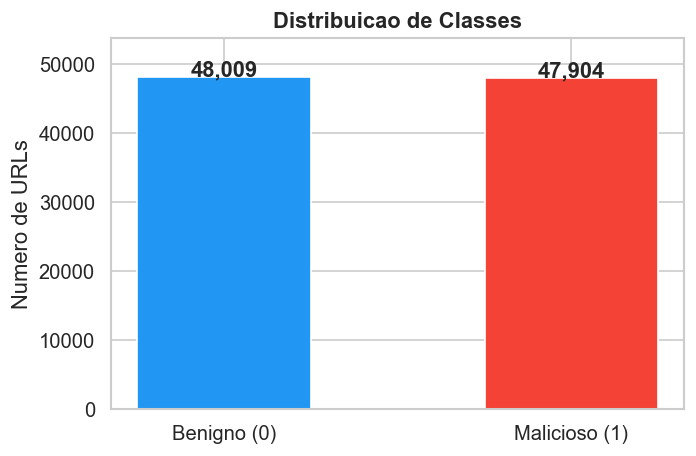

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Benigno (0)', 'Malicioso (1)'], contagem.values,
              color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Distribuicao de Classes', fontweight='bold')
ax.set_ylabel('Numero de URLs')
ax.set_ylim(0, contagem.max() * 1.12)
plt.tight_layout()
plt.savefig('fig1_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Identificacao de Problemas


In [9]:
# 4.1 Valores nulos
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')

Valores nulos por coluna:
domain           0
ranking          0
mld_res          0
mld.ps_res       0
card_rem         0
ratio_Rrem       0
ratio_Arem       0
jaccard_RR       0
jaccard_RA       0
jaccard_AR       0
jaccard_AA       0
jaccard_ARrd     0
jaccard_ARrem    0
label            0
dtype: int64

Total de nulos: 0


In [10]:
# 4.2 Duplicados
n_dup_total  = df.duplicated().sum()
n_dup_domain = df['domain'].duplicated().sum()
print(f'Linhas completamente duplicadas : {n_dup_total}')
print(f'Dominios duplicados             : {n_dup_domain}')

if n_dup_total > 0:
    print('\nLinhas duplicadas:')
    print(df[df.duplicated(keep=False)][['domain', 'label']])

Linhas completamente duplicadas : 1
Dominios duplicados             : 2

Linhas duplicadas:
                       domain  label
12011  bin/webscr?cmd=_login-      1
35319  bin/webscr?cmd=_login-      1


In [11]:
# 4.3 Valores nao numericos na coluna ranking
ranking_invalido = df[pd.to_numeric(df['ranking'], errors='coerce').isna()]
print(f'Linhas com ranking invalido: {len(ranking_invalido)}')

if len(ranking_invalido) > 0:
    print('\nDetalhes:')
    print(ranking_invalido[['domain', 'ranking', 'label']])

Linhas com ranking invalido: 1

Detalhes:
                 domain                                            ranking  \
18231  è kvüDâQÎé4¼Ò©  Ý&öëåEÐä¢¶Åj½ÛF4È:t`IbÔmÔ6­ò2G«ü¬my...   

       label  
18231      1  


In [12]:
# 4.4 Outliers nas colunas continuas (metodo IQR)
colunas_continuas = ['card_rem', 'ratio_Rrem', 'ratio_Arem']

print(f'{"Coluna":<15}  {"Min":>8}  {"Max":>10}  {"Limite IQR":>12}  {"Outliers":>10}')
print('-' * 65)
for col in colunas_continuas:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    lim = Q3 + 1.5 * (Q3 - Q1)
    n   = (df[col] > lim).sum()
    pct = n / len(df) * 100
    print(f'{col:<15}  {df[col].min():>8.2f}  {df[col].max():>10.2f}  {lim:>12.2f}  {n:>7,} ({pct:.1f}%)')

Coluna                Min         Max    Limite IQR    Outliers
-----------------------------------------------------------------
card_rem             0.00       58.00         12.00    5,226 (5.4%)
ratio_Rrem           0.00     5507.00        370.86    4,626 (4.8%)
ratio_Arem           0.00     6097.00        386.33    4,754 (5.0%)


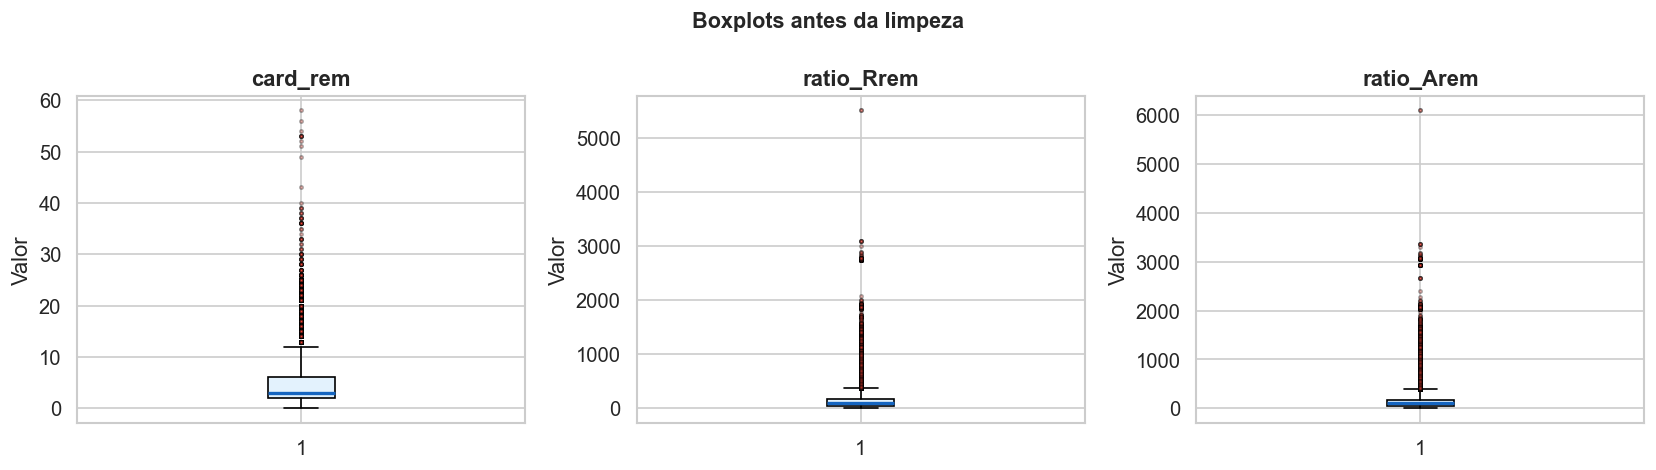

In [13]:
# Boxplots das colunas com outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, colunas_continuas):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#e3f2fd'),
               medianprops=dict(color='#1565c0', linewidth=2),
               flierprops=dict(marker='o', markersize=2,
                               markerfacecolor='#F44336', alpha=0.3))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Valor')
plt.suptitle('Boxplots antes da limpeza', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_outliers_antes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Limpeza dos Dados

In [14]:
df_clean = df.copy()
print(f'Linhas antes da limpeza: {len(df_clean):,}')
print()

# 1. Remover registo corrompido
idx_corrompido = df_clean[pd.to_numeric(df_clean['ranking'], errors='coerce').isna()].index
df_clean = df_clean.drop(index=idx_corrompido)
print(f'[1] Registos corrompidos removidos : {len(idx_corrompido)}')

# 2. Remover duplicados
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'[2] Duplicados removidos           : {n_antes - len(df_clean)}')

# 3. Converter ranking para inteiro
df_clean['ranking'] = pd.to_numeric(df_clean['ranking'], errors='coerce').astype('Int64')
print('[3] ranking convertido             : string -> inteiro')

# 4. Capping de outliers pelo IQR
for col in colunas_continuas:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    lim = Q3 + 1.5 * (Q3 - Q1)
    n_clip = (df_clean[col] > lim).sum()
    df_clean[col] = df_clean[col].clip(upper=lim)
    print(f'[4] Outliers tratados em {col:<12}: {n_clip:,} valores limitados a {lim:.2f}')

print()
print(f'Linhas apos limpeza : {len(df_clean):,}')
print(f'Linhas removidas    : {len(df) - len(df_clean)}')

Linhas antes da limpeza: 95,913

[1] Registos corrompidos removidos : 1
[2] Duplicados removidos           : 1
[3] ranking convertido             : string -> inteiro
[4] Outliers tratados em card_rem    : 5,226 valores limitados a 12.00
[4] Outliers tratados em ratio_Rrem  : 4,626 valores limitados a 370.86
[4] Outliers tratados em ratio_Arem  : 4,756 valores limitados a 386.23

Linhas apos limpeza : 95,911
Linhas removidas    : 2


## 6. Verificacao Pós-Limpeza

In [15]:
print('Valores nulos apos limpeza:')
print(df_clean.isnull().sum())
print(f'\nDuplicados apos limpeza : {df_clean.duplicated().sum()}')
print(f'Tipo de ranking         : {df_clean["ranking"].dtype}')

Valores nulos apos limpeza:
domain           0
ranking          0
mld_res          0
mld.ps_res       0
card_rem         0
ratio_Rrem       0
ratio_Arem       0
jaccard_RR       0
jaccard_RA       0
jaccard_AR       0
jaccard_AA       0
jaccard_ARrd     0
jaccard_ARrem    0
label            0
dtype: int64

Duplicados apos limpeza : 0
Tipo de ranking         : Int64


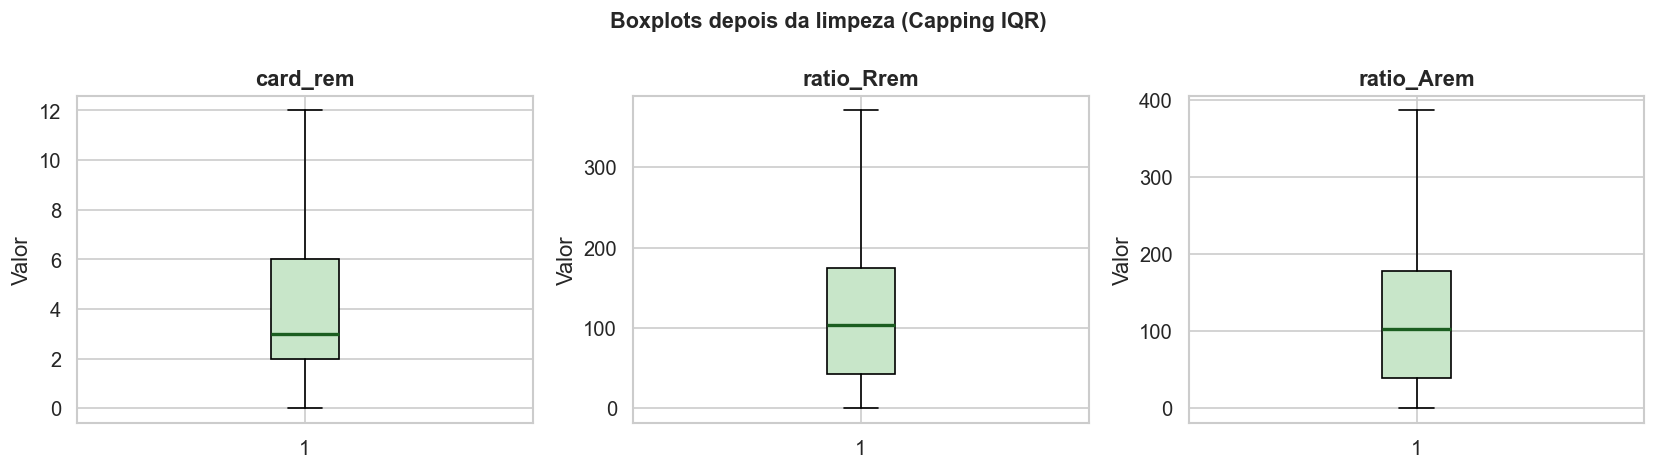

In [16]:
# Boxplots depois da limpeza
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, colunas_continuas):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#c8e6c9'),
               medianprops=dict(color='#1b5e20', linewidth=2),
               flierprops=dict(marker='o', markersize=2,
                               markerfacecolor='#388e3c', alpha=0.3))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Valor')
plt.suptitle('Boxplots depois da limpeza (Capping IQR)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_outliers_depois.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
contagem_clean = df_clean['label'].value_counts()
pct_clean      = df_clean['label'].value_counts(normalize=True) * 100
print('Distribuicao de classes apos limpeza:')
print(f'  Benigno   (0): {contagem_clean[0]:,}  ({pct_clean[0]:.1f}%)')
print(f'  Malicioso (1): {contagem_clean[1]:,}  ({pct_clean[1]:.1f}%)')

Distribuicao de classes apos limpeza:
  Benigno   (0): 48,009  (50.1%)
  Malicioso (1): 47,902  (49.9%)


## 7. Exportação do Dataset Limpo

In [18]:
df_clean.to_csv('urldata_clean.csv', index=False, encoding='utf-8')
print(f'Guardado: urldata_clean.csv')
print(f'  {len(df_clean):,} linhas x {df_clean.shape[1]} colunas')

Guardado: urldata_clean.csv
  95,911 linhas x 14 colunas
